<a href="https://colab.research.google.com/github/TAUforPython/NeuralODE/blob/main/NeuralODE_Temporal_Neural_Operator_Oscillator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Temporal Neural Operator

https://arxiv.org/pdf/2504.20249

In [1]:
!pip install torch -q

Using device: cpu
--- Generating Damped Oscillator Data ---
Raw Data Shapes: X=(1500, 50), Y=(1500, 50)
Input shape: torch.Size([1200, 50, 1])
Target shape: torch.Size([1200, 50, 1])
--- Data Generation Complete ---
--- Defining Simplified TNO for Oscillator ---
--- Model Defined ---
--- Starting Training ---
Epoch [50/150], Loss: 0.457519
Epoch [100/150], Loss: 0.131170
Epoch [150/150], Loss: 0.050110
--- Training Complete ---
--- Evaluating Model ---
Test MSE: 0.006400
Test RMSE: 0.079998
--- Evaluation Complete ---
--- Plotting Predictions ---


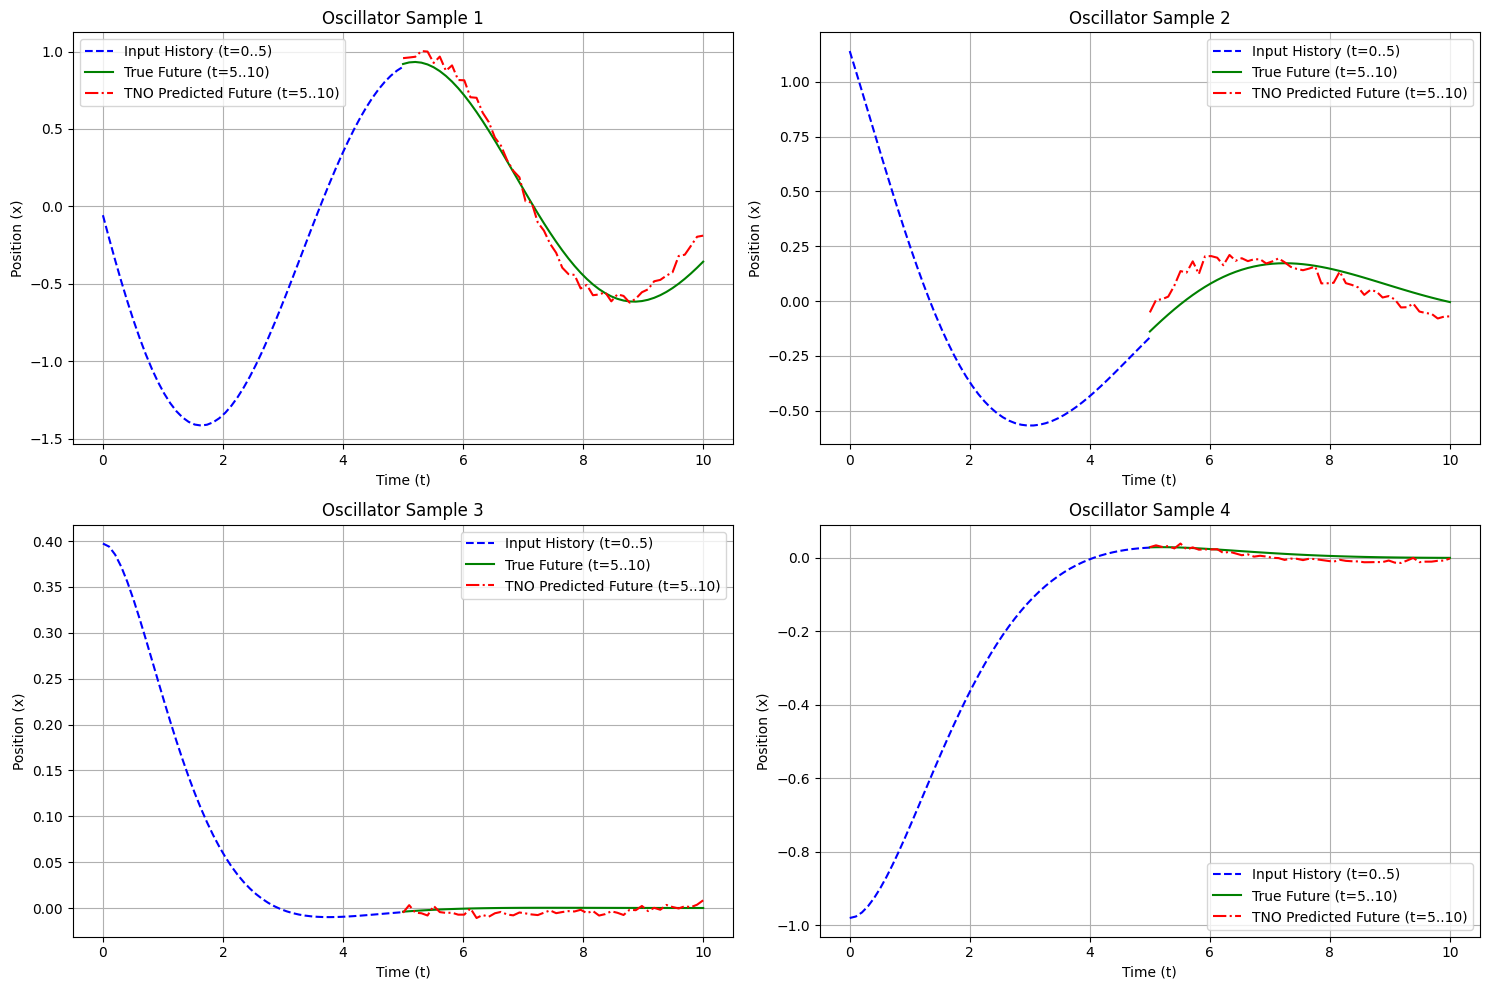

--- Plotting Complete ---


In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 1. Data Generation: Damped Harmonic Oscillator ---
def simulate_oscillator(initial_conditions, params, t_eval, dt=0.01):
  """
  Simulates a damped harmonic oscillator: m*x'' + c*x' + k*x = 0
  Rewritten as: x'' = -(c/m)*x' - (k/m)*x
  Or as a system of first-order ODEs:
  dx/dt = v
  dv/dt = -(c/m)*v - (k/m)*x
  """
  x0, v0 = initial_conditions
  mass, damping_coeff, spring_const = params
  gamma = damping_coeff / (2 * mass)
  omega0_sq = spring_const / mass

  # Calculate intermediate terms for the analytical solution
  discriminant = gamma**2 - omega0_sq

  if discriminant > 0: # Overdamped
      r_plus = -gamma + np.sqrt(discriminant)
      r_minus = -gamma - np.sqrt(discriminant)
      A = (v0 - r_minus * x0) / (r_plus - r_minus)
      B = (r_plus * x0 - v0) / (r_plus - r_minus)
      x_vals = A * np.exp(r_plus * t_eval) + B * np.exp(r_minus * t_eval)
  elif discriminant == 0: # Critically damped
      A = x0
      B = v0 + gamma * x0
      x_vals = (A + B * t_eval) * np.exp(-gamma * t_eval)
  else: # Underdamped
      omega_d = np.sqrt(omega0_sq - gamma**2)
      A = x0
      B = (v0 + gamma * x0) / omega_d
      envelope = np.exp(-gamma * t_eval)
      oscillation = A * np.cos(omega_d * t_eval) + B * np.sin(omega_d * t_eval)
      x_vals = envelope * oscillation

  # Approximate velocity using central differences for simplicity in this example
  # A more rigorous approach might involve predicting both x and v simultaneously.
  # For this example, we'll just calculate velocity from the analytical x(t) if needed.
  # We'll primarily focus on predicting position x.
  return x_vals

def generate_oscillator_data(n_samples=1000, seq_len=100, t_max=10.0):
  """
  Generates sequences of oscillator displacement over time.
  Each sample has different initial conditions and possibly parameters.
  """
  X = [] # Input sequences (e.g., history of x and/or v)
  Y = [] # Target sequences (e.g., future x)

  dt = t_max / seq_len
  t_full = np.linspace(0, t_max, seq_len)

  for _ in range(n_samples):
      # Random initial conditions
      x0 = np.random.uniform(-2.0, 2.0)
      v0 = np.random.uniform(-2.0, 2.0)
      initial_conditions = (x0, v0)

      # Random parameters for the oscillator (keeping mass fixed for simplicity)
      # Ensuring stable (non-growing) solutions by limiting damping
      mass = 1.0
      damping_coeff = np.random.uniform(0.0, 2.0) # 0 = undamped, > 2*sqrt(k/m) = overdamped
      spring_const = np.random.uniform(0.5, 2.0)
      params = (mass, damping_coeff, spring_const)

      # Generate the full sequence
      full_sequence = simulate_oscillator(initial_conditions, params, t_full, dt)

      # For this example, let's define the problem as predicting the *next* half of the sequence
      # given the first half as input. This mimics the temporal dynamics prediction task in TNO.
      # Input: first half of the sequence (e.g., x(t=0...t_max/2))
      input_seq = full_sequence[:seq_len//2]
      # Target: second half of the sequence (e.g., x(t=t_max/2...t_max))
      target_seq = full_sequence[seq_len//2:]

      X.append(input_seq)
      Y.append(target_seq)

  return np.array(X), np.array(Y)

print("--- Generating Damped Oscillator Data ---")
X_raw, Y_raw = generate_oscillator_data(n_samples=1500, seq_len=100, t_max=10.0)
print(f"Raw Data Shapes: X={X_raw.shape}, Y={Y_raw.shape}")

# Normalize the data
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_raw.reshape(-1, X_raw.shape[-1])).reshape(X_raw.shape)
Y_scaled = scaler_Y.fit_transform(Y_raw.reshape(-1, Y_raw.shape[-1])).reshape(Y_raw.shape)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(X_scaled).unsqueeze(-1) # Add channel dim: (N, seq_len//2, 1)
Y_tensor = torch.FloatTensor(Y_scaled).unsqueeze(-1) # Add channel dim: (N, seq_len//2, 1)

# Train/test split
split_idx = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:split_idx], X_tensor[split_idx:]
Y_train, Y_test = Y_tensor[:split_idx], Y_tensor[split_idx:]
print(f"Input shape: {X_train.shape}")
print(f"Target shape: {Y_train.shape}")
print("--- Data Generation Complete ---")

# --- 2. TNO-Inspired Model for Oscillator ---
# Adapted from the previous 1D series example, focusing on temporal dynamics.
# The 'temporal branch' processes the input history sequence.
# The 'trunk' processes the target time indices (implicitly defining the output shape/time points).
class TemporalBranch_Osc(nn.Module):
    """Processes the temporal history (e.g., x_history) using an LSTM."""
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len_history, input_features=1)
        lstm_out, _ = self.lstm(x)
        # Take the last output of the LSTM representing the learned state
        last_output = lstm_out[:, -1, :] # (batch, hidden_size)
        output = self.fc(last_output) # (batch, output_size)
        return output # This represents the system state based on history

class TrunkNetwork_Osc(nn.Module):
    """Processes the temporal query points (target time indices)."""
    def __init__(self, n_time_points, output_size):
        super().__init__()
        # Embedding for each time step in the target sequence
        self.time_embedding = nn.Embedding(n_time_points, output_size)

    def forward(self, x):
        # x is a dummy input here, just to infer batch size and target length
        batch_size, seq_len, _ = x.shape
        time_indices = torch.arange(seq_len, dtype=torch.long, device=x.device).expand(batch_size, -1)
        # Embed time indices
        time_emb = self.time_embedding(time_indices) # (batch, seq_len, output_size)
        return time_emb

class SimplifiedTNODynamicSystem(nn.Module):
    """
    A simplified TNO model tailored for a dynamic system like an oscillator.
    It uses a temporal branch to encode the system's state from the history,
    a trunk to encode the target time points, and combines them to predict the output trajectory.
    """
    def __init__(self, input_size=1, hidden_size=128, trunk_size=128, output_size=50):
        super().__init__()
        self.temporal_branch = TemporalBranch_Osc(input_size, hidden_size, trunk_size)
        self.trunk_network = TrunkNetwork_Osc(output_size, trunk_size) # trunk_size matches latent dim
        self.decoder = nn.Linear(trunk_size, 1) # Map latent features to single output value (e.g., x(t))
        self.output_size = output_size

    def forward(self, x_history):
        # x_history shape: (batch, seq_len_history, input_features=1)

        # Process history through temporal branch to get state representation
        # Output: (batch, trunk_size)
        temporal_features = self.temporal_branch(x_history)

        # Repeat the state representation for each target time step
        # Shape becomes (batch, output_size, trunk_size)
        repeated_state = temporal_features.unsqueeze(1).repeat(1, self.output_size, 1)

        # Process target time coordinates through trunk
        # Dummy input for trunk - just needs shape info to get correct target length
        dummy_input_for_trunk = torch.zeros_like(x_history[:, :self.output_size, :])
        trunk_features = self.trunk_network(dummy_input_for_trunk) # (batch, output_size, trunk_size)

        # Combine state and time features (inspired by TNO's Hadamard product)
        # This allows the state representation to influence the prediction at each time step,
        # modulated by the time-specific features.
        combined_features = repeated_state * trunk_features # (batch, output_size, trunk_size)

        # Decode to final output sequence
        output = self.decoder(combined_features).squeeze(-1) # (batch, output_size)

        return output

print("--- Defining Simplified TNO for Oscillator ---")
model_osc = SimplifiedTNODynamicSystem(input_size=1, hidden_size=128, trunk_size=128, output_size=Y_train.shape[1]).to(device)
criterion_osc = nn.MSELoss()
optimizer_osc = torch.optim.Adam(model_osc.parameters(), lr=0.001)
print("--- Model Defined ---")

# --- 3. Training ---
print("--- Starting Training ---")
num_epochs_osc = 150
for epoch in range(num_epochs_osc):
    model_osc.train()
    optimizer_osc.zero_grad()

    outputs = model_osc(X_train.to(device))
    loss = criterion_osc(outputs, Y_train.to(device).squeeze(-1))

    loss.backward()
    optimizer_osc.step()

    if (epoch+1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs_osc}], Loss: {loss.item():.6f}')

print("--- Training Complete ---")

# --- 4. Evaluation and Visualization ---
print("--- Evaluating Model ---")
model_osc.eval()
with torch.no_grad():
    test_outputs = model_osc(X_test.to(device))
    test_loss = criterion_osc(test_outputs, Y_test.to(device).squeeze(-1))
    # Inverse transform predictions and targets
    test_outputs_np = scaler_Y.inverse_transform(test_outputs.cpu().numpy())
    Y_test_np = scaler_Y.inverse_transform(Y_test.squeeze(-1).cpu().numpy())

    mse = mean_squared_error(Y_test_np, test_outputs_np)
    rmse = np.sqrt(mse)

print(f'Test MSE: {mse:.6f}')
print(f'Test RMSE: {rmse:.6f}')
print("--- Evaluation Complete ---")

# Visualization
print("--- Plotting Predictions ---")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

# Generate time vectors for plotting
dt_sim = 10.0 / 100 # Total time / total sequence length
t_input = np.linspace(0, 5.0, num=X_train.shape[1]) # First half (0 to 5)
t_target = np.linspace(5.0, 10.0, num=Y_train.shape[1]) # Second half (5 to 10)

for i in range(min(4, len(X_test))):
    # Inverse transform for plotting
    x_input_plot = scaler_X.inverse_transform(X_test[i].cpu().numpy().reshape(1, -1)).ravel()
    y_true_plot = Y_test_np[i]
    y_pred_plot = test_outputs_np[i]

    axes[i].plot(t_input, x_input_plot, label='Input History (t=0..5)', linestyle='--', color='blue')
    axes[i].plot(t_target, y_true_plot, label='True Future (t=5..10)', color='green')
    axes[i].plot(t_target, y_pred_plot, label='TNO Predicted Future (t=5..10)', color='red', linestyle='-.')
    axes[i].set_title(f'Oscillator Sample {i+1}')
    axes[i].set_xlabel('Time (t)')
    axes[i].set_ylabel('Position (x)')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()
print("--- Plotting Complete ---")

# Use model of Second order system

In [4]:
!pip install control -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 12.5 MB/s eta 0:00:00


Using device: cpu
--- Generating Damped Oscillator Step Response Data ---
Raw Data Shapes: X=(1200, 100), Y=(1200, 100), P=(1200,)
Train shapes: X=torch.Size([960, 100, 1]), Y=torch.Size([960, 100, 1]), P=torch.Size([960])
Test shapes: X=torch.Size([240, 100, 1]), Y=torch.Size([240, 100, 1]), P=torch.Size([240])
--- Data Generation and Preprocessing Complete ---
--- Defining Complex TNO Model for Control System ---
--- Model Defined ---
--- Starting Training ---
Epoch [50/200], Loss: 0.325769
Epoch [100/200], Loss: 0.166964
Epoch [150/200], Loss: 0.082035
Epoch [200/200], Loss: 0.057608
--- Training Complete ---
--- Evaluating Model ---
Test MSE: 0.000468
Test RMSE: 0.021632
--- Evaluation Complete ---
--- Plotting Predictions ---


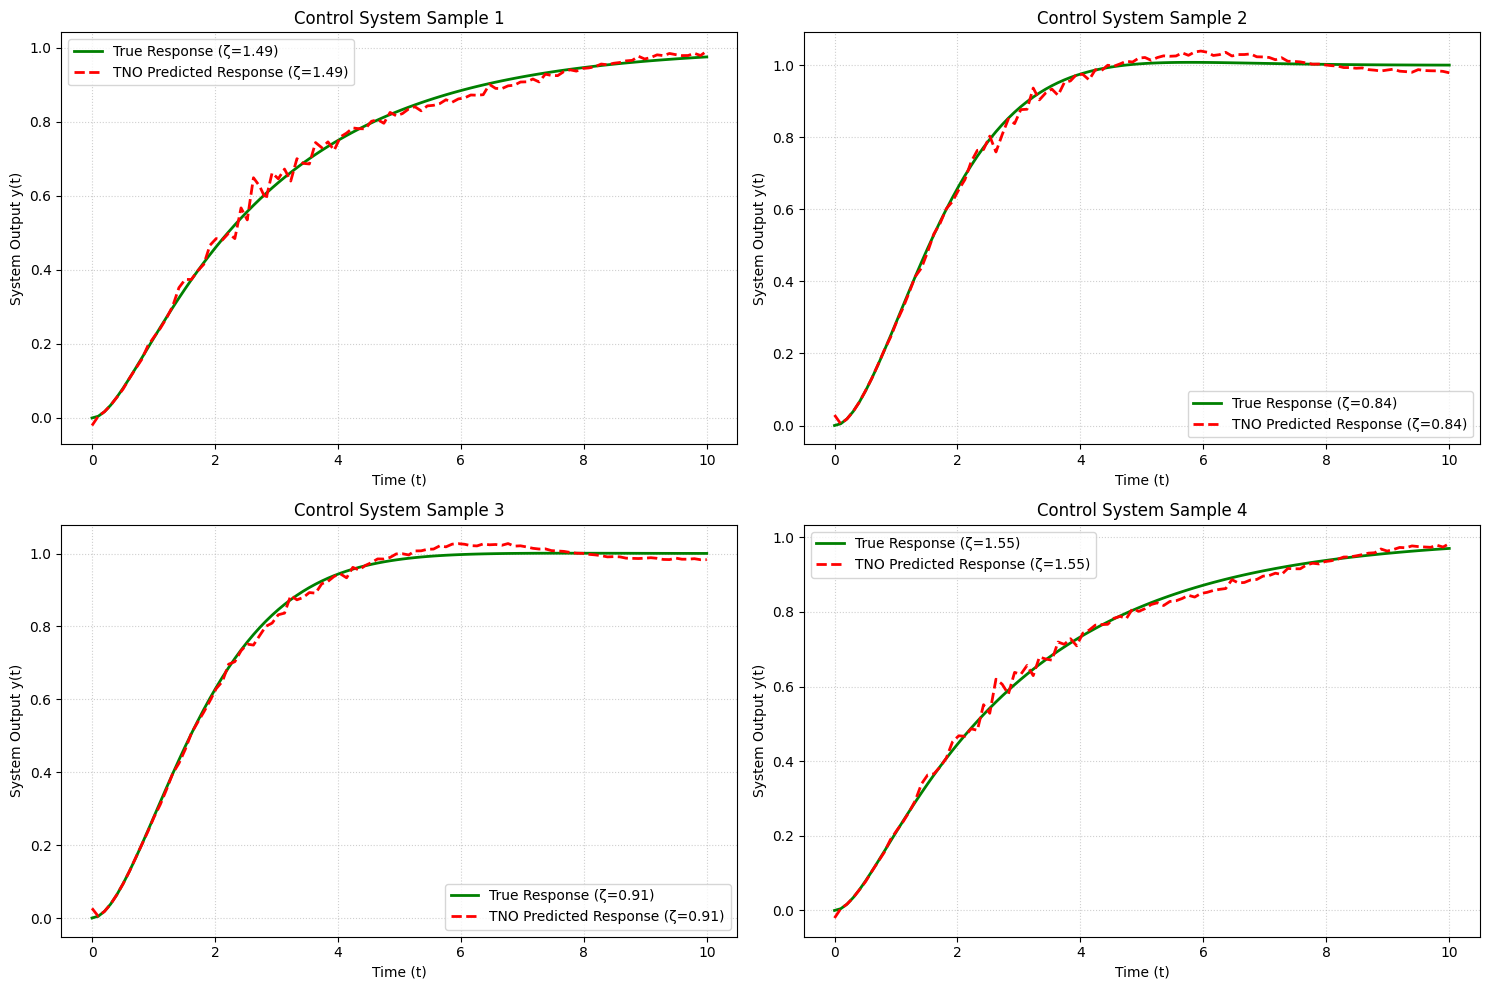

--- Plotting Complete ---
--- Verifying with True Control Theory Responses ---


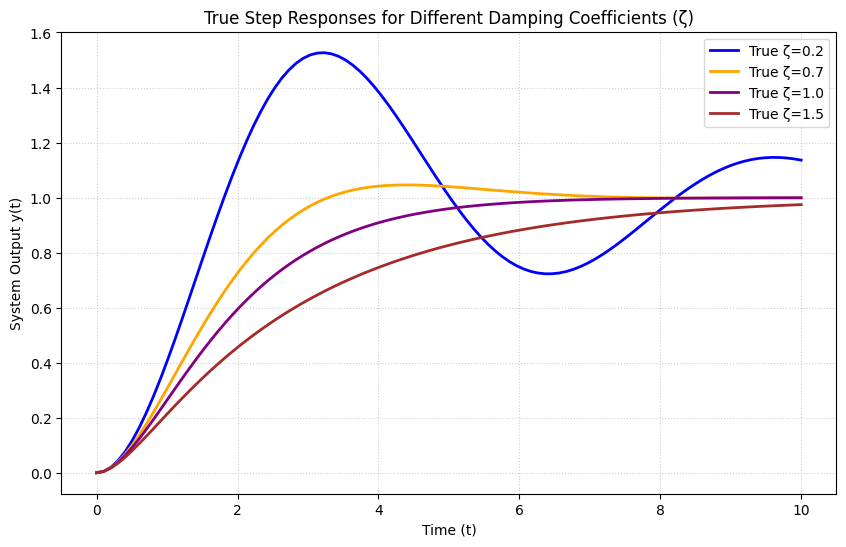

--- Verification Complete ---


In [6]:
# Install the 'control' library if running in a fresh environment
# Uncomment the line below if necessary
# !pip install control

import control # For system modeling and simulation
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 1. Data Generation: Step Response of Damped Oscillator ---
def generate_step_response_data(n_samples=1000, t_max=10.0, n_timepoints=100):
    """
    Generates step response data for a damped oscillator system.
    System: G(s) = w_n^2 / (s^2 + 2*zeta*w_n*s + w_n^2)
    Input: Unit step (constant 1)
    Parameters: Damping coefficient (zeta), Natural frequency (w_n) - kept constant here.
    Output: System response y(t) to the step input.
    """
    X = [] # Input signals (e.g., unit step) - shape (n_samples, n_timepoints, 1)
    Y = [] # Output signals (step responses) - shape (n_samples, n_timepoints, 1)
    P = [] # Parameter vector (e.g., damping coefficient) - shape (n_samples, 1)

    w_n = 1.0 # Natural frequency (fixed for simplicity)
    t = np.linspace(0, t_max, n_timepoints)

    for _ in range(n_samples):
        # Random damping coefficient (zeta)
        # zeta < 1: Underdamped, zeta = 1: Critically damped, zeta > 1: Overdamped
        zeta = np.random.uniform(0.1, 2.0)

        # Define the transfer function G(s)
        num = [w_n**2]
        den = [1, 2*zeta*w_n, w_n**2]
        sys = control.TransferFunction(num, den)

        # Simulate the step response
        _, y_out = control.step_response(sys, T=t)

        # Ensure output has the correct length (numerical issues sometimes cause slight mismatches)
        if len(y_out) != n_timepoints:
            y_out = np.interp(t, np.linspace(0, t_max, len(y_out)), y_out)

        # Prepare input (unit step), output (response), and parameter
        x_signal = np.ones_like(y_out) # Unit step input
        X.append(x_signal)
        Y.append(y_out)
        P.append(zeta)

    return np.array(X), np.array(Y), np.array(P)

print("--- Generating Damped Oscillator Step Response Data ---")
X_raw, Y_raw, P_raw = generate_step_response_data(n_samples=1200, t_max=10.0, n_timepoints=100)
print(f"Raw Data Shapes: X={X_raw.shape}, Y={Y_raw.shape}, P={P_raw.shape}")

# --- 2. Data Preprocessing and Scaling ---
# The parameter 'P' needs to be incorporated. We'll use the MIONet approach adapted for TNO.
# The 'branch' network will process the parameter P and the input signal X concatenated together.
# The 'trunk' network processes time coordinates.
# The 't-branch' is adapted to process the input signal history if needed, or the parameter history.
# For this example, focusing on the parameter P and single input/output step, we simplify:
# - Branch: Concatenates normalized P (repeated for time dimension) and normalized X
# - Trunk: Processes time coordinates
# - t-Branch: Processes the input signal X (or its history if bundling K>1)

# Normalize X and Y independently
scaler_X = StandardScaler()
scaler_Y = StandardScaler()
scaler_P = StandardScaler()

X_scaled = scaler_X.fit_transform(X_raw.reshape(-1, X_raw.shape[-1])).reshape(X_raw.shape)
Y_scaled = scaler_Y.fit_transform(Y_raw.reshape(-1, Y_raw.shape[-1])).reshape(Y_raw.shape)
P_scaled = scaler_P.fit_transform(P_raw.reshape(-1, 1)).ravel() # Shape (n_samples,)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(X_scaled).unsqueeze(-1) # Shape: (N, seq_len, 1)
Y_tensor = torch.FloatTensor(Y_scaled).unsqueeze(-1) # Shape: (N, seq_len, 1)
P_tensor = torch.FloatTensor(P_scaled)              # Shape: (N,)

# Train/test split
split_idx = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:split_idx], X_tensor[split_idx:]
Y_train, Y_test = Y_tensor[:split_idx], Y_tensor[split_idx:]
P_train, P_test = P_tensor[:split_idx], P_tensor[split_idx:]

print(f"Train shapes: X={X_train.shape}, Y={Y_train.shape}, P={P_train.shape}")
print(f"Test shapes: X={X_test.shape}, Y={Y_test.shape}, P={P_test.shape}")
print("--- Data Generation and Preprocessing Complete ---")

# --- 3. Modified TNO Model Definition ---
# Incorporates the parameter P using a branch network concept.
# The temporal branch (t-branch) processes the input signal X.
# The main branch processes the parameter P.
# The trunk processes time coordinates.

class TemporalBranch_Control(nn.Module):
    """Processes the temporal input signal history X."""
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, input_features=1)
        lstm_out, _ = self.lstm(x)
        # Use the last output for the final time step prediction context
        # For bundling K=1, we might just pass the full sequence features or aggregate differently.
        # Here, we take the last state as a summary for interaction with other branches.
        last_output = lstm_out[:, -1, :] # (batch, hidden_size)
        output = self.fc(last_output) # (batch, output_size)
        return output # Shape: (batch, output_size)

class MainBranch_Control(nn.Module):
    """Processes the input parameter P (damping coefficient)."""
    def __init__(self, param_size, hidden_size, output_size):
        super().__init__()
        # Process the single parameter value
        self.fc1 = nn.Linear(param_size, hidden_size)
        self.act = nn.Tanh()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, p):
        # p shape: (batch,)
        p_expanded = p.unsqueeze(-1) # (batch, 1)
        h = self.act(self.fc1(p_expanded)) # (batch, hidden_size)
        output = self.fc2(h) # (batch, output_size)
        return output # Shape: (batch, output_size)

class TrunkNetwork_Control(nn.Module):
    """Processes the temporal query points (time indices)."""
    def __init__(self, n_time_points, output_size):
        super().__init__()
        self.time_embedding = nn.Embedding(n_time_points, output_size)

    def forward(self, x):
        # x is used only to infer batch size and sequence length
        batch_size, seq_len, _ = x.shape
        time_indices = torch.arange(seq_len, dtype=torch.long, device=x.device).expand(batch_size, -1)
        time_emb = self.time_embedding(time_indices) # (batch, seq_len, output_size)
        return time_emb

class ComplexSimplifiedTNOControl(nn.Module):
    """
    A TNO model adapted for control system identification.
    Branch: Processes parameter P.
    t-Branch: Processes input signal X.
    Trunk: Processes time coordinates.
    Combines features and predicts the full output sequence Y.
    """
    def __init__(self, input_size=1, param_size=1, hidden_size=128, trunk_size=128, output_size=100):
        super().__init__()
        self.t_branch = TemporalBranch_Control(input_size, hidden_size, trunk_size)
        self.branch = MainBranch_Control(param_size, hidden_size, trunk_size)
        self.trunk_network = TrunkNetwork_Control(output_size, trunk_size)
        self.decoder = nn.Linear(trunk_size, 1) # Map to single output value per time step
        self.output_size = output_size

    def forward(self, x_signal, p_param):
        # x_signal: (batch, seq_len, 1)
        # p_param: (batch,)

        # Process input signal through t-branch
        t_features = self.t_branch(x_signal) # (batch, trunk_size)

        # Process parameter through branch
        b_features = self.branch(p_param) # (batch, trunk_size)

        # Process time coordinates through trunk
        # Need to pass a tensor with the correct shape for time length
        t_coords = self.trunk_network(x_signal) # (batch, seq_len, trunk_size)

        # Combine features (e.g., outer product-like interaction, then sum or Hadamard with coords)
        # Interaction between state (from signal) and parameter
        combined_bp = b_features.unsqueeze(1) * t_features.unsqueeze(1) # (batch, 1, trunk_size) * (batch, 1, trunk_size) -> (batch, 1, trunk_size)
        # Expand combined_bp to match time dimension of trunk coords
        combined_bp_expanded = combined_bp.expand(-1, self.output_size, -1) # (batch, seq_len, trunk_size)

        # Combine with time-dependent features
        final_features = combined_bp_expanded * t_coords # (batch, seq_len, trunk_size)

        # Decode to final output sequence
        output = self.decoder(final_features).squeeze(-1) # (batch, seq_len)

        return output

print("--- Defining Complex TNO Model for Control System ---")
model_ctrl = ComplexSimplifiedTNOControl(
    input_size=1, param_size=1, hidden_size=128, trunk_size=128, output_size=Y_train.shape[1]
).to(device)
criterion_ctrl = nn.MSELoss()
optimizer_ctrl = torch.optim.Adam(model_ctrl.parameters(), lr=0.001)
print("--- Model Defined ---")

# --- 4. Training ---
print("--- Starting Training ---")
num_epochs_ctrl = 200
for epoch in range(num_epochs_ctrl):
    model_ctrl.train()
    optimizer_ctrl.zero_grad()

    outputs = model_ctrl(X_train.to(device), P_train.to(device))
    loss = criterion_ctrl(outputs, Y_train.to(device).squeeze(-1))

    loss.backward()
    optimizer_ctrl.step()

    if (epoch+1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs_ctrl}], Loss: {loss.item():.6f}')

print("--- Training Complete ---")

# --- 5. Evaluation and Visualization ---
print("--- Evaluating Model ---")
model_ctrl.eval()
with torch.no_grad():
    test_outputs = model_ctrl(X_test.to(device), P_test.to(device))
    test_loss = criterion_ctrl(test_outputs, Y_test.to(device).squeeze(-1))
    # Inverse transform predictions and targets
    test_outputs_np = scaler_Y.inverse_transform(test_outputs.cpu().numpy()).reshape(test_outputs.shape)
    Y_test_np = scaler_Y.inverse_transform(Y_test.squeeze(-1).cpu().numpy()).reshape(Y_test.squeeze(-1).shape)
    P_test_np = scaler_P.inverse_transform(P_test.cpu().numpy().reshape(-1, 1)).ravel()

    mse = mean_squared_error(Y_test_np.flatten(), test_outputs_np.flatten())
    rmse = np.sqrt(mse)

print(f'Test MSE: {mse:.6f}')
print(f'Test RMSE: {rmse:.6f}')
print("--- Evaluation Complete ---")

# Visualization: Plot a few test examples comparing true and predicted responses
print("--- Plotting Predictions ---")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

# Generate time vector for plotting
t_plot = np.linspace(0, 10.0, num=Y_test.shape[1])

for i in range(min(4, len(X_test))):
    # Inverse transform for plotting
    y_true_plot = Y_test_np[i]
    y_pred_plot = test_outputs_np[i]
    p_true_val = P_test_np[i]

    axes[i].plot(t_plot, y_true_plot, label=f'True Response (ζ={p_true_val:.2f})', color='green', linewidth=2)
    axes[i].plot(t_plot, y_pred_plot, label=f'TNO Predicted Response (ζ={p_true_val:.2f})', color='red', linestyle='--', linewidth=2)
    axes[i].set_title(f'Control System Sample {i+1}')
    axes[i].set_xlabel('Time (t)')
    axes[i].set_ylabel('System Output y(t)')
    axes[i].legend()
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
print("--- Plotting Complete ---")

# --- 6. Verification: Plot True Step Responses for Different ζ Values ---
print("--- Verifying with True Control Theory Responses ---")
fig_verify, ax_verify = plt.subplots(figsize=(10, 6))

w_n = 1.0
t_verify = np.linspace(0, 10, 100)

zetas_to_show = [0.2, 0.7, 1.0, 1.5]
colors = ['blue', 'orange', 'purple', 'brown']

for zeta, col in zip(zetas_to_show, colors):
    num = [w_n**2]
    den = [1, 2*zeta*w_n, w_n**2]
    sys_verify = control.TransferFunction(num, den)
    _, y_verify = control.step_response(sys_verify, T=t_verify)
    ax_verify.plot(t_verify, y_verify, label=f'True ζ={zeta}', color=col, linestyle='-', linewidth=2)

ax_verify.set_title('True Step Responses for Different Damping Coefficients (ζ)')
ax_verify.set_xlabel('Time (t)')
ax_verify.set_ylabel('System Output y(t)')
ax_verify.legend()
ax_verify.grid(True, linestyle=':', alpha=0.6)
plt.show()
print("--- Verification Complete ---")